<a href="https://colab.research.google.com/github/binshadbin42-coder/github-tutorial/blob/main/sentimental_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ============================================
# 1. LOADING AND PREPROCESSING
# ============================================

import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# --------------------------------------------
# LOAD DATASET
# --------------------------------------------

df = pd.read_csv("/content/nlp_dataset.csv")

print("Original Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

# --------------------------------------------
# CHECK MISSING VALUES
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing rows
df = df.dropna()

print("\nDataset Shape After Removing Missing Values:")
print(df.shape)

# --------------------------------------------
# SELECT COLUMNS
# --------------------------------------------

TEXT_COLUMN = "Comment"
TARGET_COLUMN = "Emotion"

# --------------------------------------------
# STOPWORDS
# --------------------------------------------

stop_words = set(stopwords.words("english"))

# --------------------------------------------
# TEXT PREPROCESSING FUNCTION
# --------------------------------------------

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join tokens
    return " ".join(tokens)

# --------------------------------------------
# APPLY PREPROCESSING
# --------------------------------------------

df["clean_text"] = df[TEXT_COLUMN].apply(
    preprocess_text
)

# --------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------

print("\nOriginal vs Cleaned Text:")

display(
    df[
        [
            TEXT_COLUMN,
            "clean_text",
            TARGET_COLUMN
        ]
    ].head(10)
)

print("\nFinal Dataset Shape:", df.shape)


Original Dataset Shape: (5937, 2)

Columns:
['Comment', 'Emotion']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear



Missing Values:
Comment    0
Emotion    0
dtype: int64

Dataset Shape After Removing Missing Values:
(5937, 2)

Original vs Cleaned Text:


,Comment,clean_text,Emotion
0,i seriously hate one subject to death but now ...,seriously hate one subject death feel reluctan...,fear
1,im so full of life i feel appalled,im full life feel appalled,anger
2,i sit here to write i start to dig out my feel...,sit write start dig feelings think afraid acce...,fear
3,ive been really angry with r and i feel like a...,ive really angry r feel like idiot trusting fi...,joy
4,i feel suspicious if there is no one outside l...,feel suspicious one outside like rapture happe...,fear
5,i feel jealous becasue i wanted that kind of l...,feel jealous becasue wanted kind love true con...,anger
6,when a friend of mine keeps telling me morbid ...,friend mine keeps telling morbid things happen...,anger
7,i finally fell asleep feeling angry useless an...,finally fell asleep feeling angry useless stil...,anger
8,i feel a bit annoyed and antsy in a good way,feel bit annoyed antsy good way,anger
9,i feel like i ve regained another vital part o...,feel like regained another vital part life living,joy



Final Dataset Shape: (5937, 3)


In [8]:
# ============================================
# 2. FEATURE EXTRACTION USING TF-IDF
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# --------------------------------------------
# INPUT AND TARGET
# --------------------------------------------

X = df["clean_text"]
y = df[TARGET_COLUMN]

# --------------------------------------------
# TRAIN-TEST SPLIT
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# --------------------------------------------
# TF-IDF VECTORIZER
# --------------------------------------------

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

# --------------------------------------------
# FIT AND TRANSFORM TRAINING DATA
# --------------------------------------------

X_train_tfidf = tfidf.fit_transform(X_train)

# --------------------------------------------
# TRANSFORM TESTING DATA
# --------------------------------------------

X_test_tfidf = tfidf.transform(X_test)

# --------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------

print("\nTF-IDF Feature Extraction Completed")

print("Training TF-IDF Shape:",
      X_train_tfidf.shape)

print("Testing TF-IDF Shape:",
      X_test_tfidf.shape)

print("Number of Features:",
      len(tfidf.get_feature_names_out()))

print("\nFirst 30 Features:")

print(
    tfidf.get_feature_names_out()[:30]
)


Training Samples: 4749
Testing Samples: 1188

TF-IDF Feature Extraction Completed
Training TF-IDF Shape: (4749, 10000)
Testing TF-IDF Shape: (1188, 10000)
Number of Features: 10000

First 30 Features:
['aa' 'aac' 'aac feeling' 'aaron' 'aaron friends' 'abandon' 'abandon sake'
 'abandoned' 'abandoned feel' 'abandoned someone' 'abandonment'
 'abandonment embrace' 'abbigail' 'abbigail apraxia' 'abc' 'abc family'
 'abc link' 'abc news' 'abdomen' 'abdomen pelvis' 'abelard' 'abide'
 'abide political' 'abilities' 'ability' 'ability artistic' 'ability bite'
 'ability feeling' 'ability get' 'ability mourn']


In [10]:
# ============================================
# 3. MODEL DEVELOPMENT
# ============================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ============================================
# MODEL 1: NAIVE BAYES
# ============================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(
    X_test_tfidf
)

print("Naive Bayes Model Trained Successfully")


# ============================================
# MODEL 2: SUPPORT VECTOR MACHINE
# ============================================

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_tfidf
)

print("SVM Model Trained Successfully")

Naive Bayes Model Trained Successfully
SVM Model Trained Successfully


In [11]:
# ============================================
# 4. MODEL COMPARISON
# ============================================

from sklearn.metrics import accuracy_score, f1_score

# --------------------------------------------
# NAIVE BAYES
# --------------------------------------------

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

# --------------------------------------------
# SVM
# --------------------------------------------

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

# --------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------

print("Naive Bayes")
print("Accuracy :", round(nb_accuracy, 4))
print("F1 Score :", round(nb_f1, 4))

print("\nSupport Vector Machine")
print("Accuracy :", round(svm_accuracy, 4))
print("F1 Score :", round(svm_f1, 4))

Naive Bayes
Accuracy : 0.9133
F1 Score : 0.9133

Support Vector Machine
Accuracy : 0.9402
F1 Score : 0.9402


In [12]:
# ============================================
# COMPARISON TABLE
# ============================================

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Support Vector Machine"
    ],
    "Accuracy": [
        nb_accuracy,
        svm_accuracy
    ],
    "F1 Score": [
        nb_f1,
        svm_f1
    ]
})

display(results)

,Model,Accuracy,F1 Score
0,Naive Bayes,0.913300,0.913324
1,Support Vector Machine,0.940236,0.940185


In [13]:
from sklearn.metrics import classification_report

print("========== NAIVE BAYES ==========")

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

print("\n========== SVM ==========")

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

========== NAIVE BAYES ==========
              precision    recall  f1-score   support

       anger       0.91      0.91      0.91       400
        fear       0.90      0.93      0.91       388
         joy       0.93      0.91      0.92       400

    accuracy                           0.91      1188
   macro avg       0.91      0.91      0.91      1188
weighted avg       0.91      0.91      0.91      1188


========== SVM ==========
              precision    recall  f1-score   support

       anger       0.94      0.92      0.93       400
        fear       0.94      0.94      0.94       388
         joy       0.95      0.96      0.95       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94      1188
weighted avg       0.94      0.94      0.94      1188



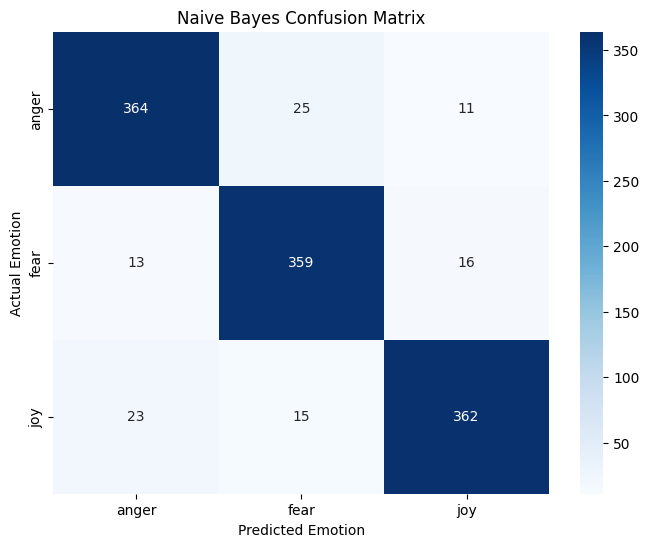

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

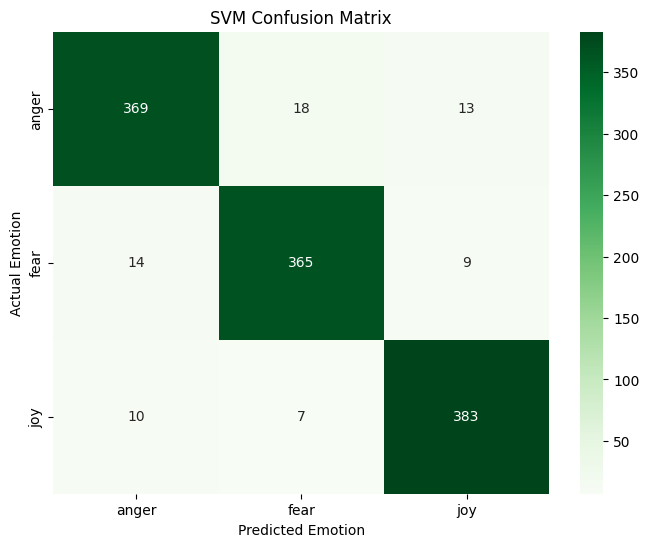

In [15]:
# SVM Confusion Matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

In [16]:
# ============================================
# FIND BEST MODEL
# ============================================

if svm_f1 > nb_f1:
    best_model = "Support Vector Machine"
    best_score = svm_f1
else:
    best_model = "Naive Bayes"
    best_score = nb_f1

print("Best Model:", best_model)
print("Best F1 Score:", round(best_score, 4))

Best Model: Support Vector Machine
Best F1 Score: 0.9402
